# Asociačné pravidlá pre úmrtie (fp-growth) - 1. vlna 

Tento notebook:
- vytvorí cieľový atribút Zomrel zo stĺpca Závažnosť priebehu ochorenia
- odstráni identifikačné a nerelevantné stĺpce
- doplní chýbajúce hodnoty pomocou robustnej MICE imputácie
- vytvorí vekové kategórie (vrátane seniorov 60+)
- automaticky vyberie štatisticky významné atribúty
- pre laboratórne markery použije výhradne posledné známe merania (s vyčisteným názvom, napr. S-Urea_Vysoke)
- vygeneruje asociačné pravidlá algoritmom fp-growth v tvare faktor(y) → Zomrel

In [1]:
# Import potrebných knižníc

import os
import re
import math
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.stats import chi2_contingency, spearmanr
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from mlxtend.frequent_patterns import fpgrowth, association_rules
from matplotlib_venn import venn2


In [2]:
# Načítanie datasetu

DATA_PATH = "1. vlna všetko 28-11-2024.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Súbor '{DATA_PATH}' sa nenašiel. Uprav DATA_PATH na správnu cestu k datasetu."
    )

if DATA_PATH.lower().endswith(".csv"):
    vlna_1 = pd.read_csv(DATA_PATH)
else:
    vlna_1 = pd.read_excel(DATA_PATH)

print("Shape pôvodného datasetu:", vlna_1.shape)
vlna_1.head()


Shape pôvodného datasetu: (1124, 274)


,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,...,ANOPYRIN,Prekonal COVID-19,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,23.11.2020,1,30.11.2020,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n...,...,False,False,183.0,183.0,183.0,183.0,13.17,13.17,13.17,13.17
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,24.12.2020,1,06.01.2021,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n,...,False,False,101.9,101.9,101.9,101.9,36.22,36.22,36.22,36.22
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,12.12.2020,1,26.12.2020,6,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | Z; _x000D_\n,...,False,False,432.7,1216.0,432.7,1216.0,6.80,6.80,6.80,6.80
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,16.12.2020,1,21.12.2020,1,J12.8 | Iný vírusový zápal pľúc | Z,B34.2 | Koronavírusová infekcia bez bližšieho ...,...,False,False,117.7,117.7,117.7,117.7,8.49,8.49,8.49,8.49
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,18.12.2020,1,21.12.2020,6,J12.8 | Iný vírusový zápal pľúc | Z,J12.8 | Iný vírusový zápal pľúc | Z; _x000D_\n,...,False,False,10979.0,10979.0,10979.0,10979.0,35.06,35.06,35.06,35.06


In [3]:
# Definovanie pomocných funkcií pre názvy stĺpcov 

def normalize_name(name: str) -> str:
    if name is None:
        return ""
    s = str(name).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"\s+", " ", s)
    return s

def first_existing_column(df, candidates):
    norm_map = {normalize_name(c): c for c in df.columns}
    for cand in candidates:
        col = norm_map.get(normalize_name(cand))
        if col is not None:
            return col
    return None

def safe_bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    if pd.api.types.is_numeric_dtype(series):
        unique = set(pd.Series(series.dropna()).unique().tolist())
        if unique.issubset({0, 1}):
            return series.fillna(0).astype(int).astype(bool)
    return None


In [4]:
# Kontrola množstva chýbajúcich hodnôt pred úpravami

severity_col = first_existing_column(vlna_1, [
    "Závažnosť priebehu ochorenia",
    "Zavaznost priebehu ochorenia"
])

if severity_col is None:
    raise KeyError("V datasete sa nenašiel stĺpec 'Závažnosť priebehu ochorenia'.")

vlna_1["Zomrel"] = vlna_1[severity_col].apply(lambda x: 1 if pd.notna(x) and x == 3 else 0).astype(int)
print(f"Úmrtia v datasete: {vlna_1['Zomrel'].sum()} z {len(vlna_1)}")

drop_candidates = [
    "ID", "id", "Kód príjmu", "Kod prijmu", "Kód prijmu",
    "Kód prepustenia", "Kod prepustenia",'HLN Dg', 'Diagnózy', 'DRG výkony', 'Mikrobiológia', 'Epikríza', 
    'Terajšie ochorenie', 'Dôvod hospitalizácie', 'Objektívny nález', 
    'Osobná anamnéza', 'Lieková anamnéza', 'Návyková anamnéza', 
    'Epidemiologická anamnéza', 'SVLZ správy', 'Liečba', "HLN Dg.", "Prekonal COVID-19", severity_col
]
cols_to_drop = [c for c in [first_existing_column(vlna_1, [cand]) for cand in drop_candidates] if c is not None]
vlna_1 = vlna_1.drop(columns=list(dict.fromkeys(cols_to_drop)), errors="ignore")

print("Shape po vytvorení cieľa a odstránení nerelevantných stĺpcov:", vlna_1.shape)
vlna_1.head()


Úmrtia v datasete: 132 z 1124
Shape po vytvorení cieľa a odstránení nerelevantných stĺpcov: (1124, 257)


,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Dátum prepustenia,A04.7,Unnamed: 23,Fajčenie,Alkohol,...,ANOPYRIN,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max,Zomrel
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,23.11.2020,30.11.2020,False,NaN,False,False,...,False,183.0,183.0,183.0,183.0,13.17,13.17,13.17,13.17,0
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,24.12.2020,06.01.2021,False,NaN,False,False,...,False,101.9,101.9,101.9,101.9,36.22,36.22,36.22,36.22,0
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,12.12.2020,26.12.2020,False,NaN,False,False,...,False,432.7,1216.0,432.7,1216.0,6.80,6.80,6.80,6.80,1
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,16.12.2020,21.12.2020,False,NaN,False,False,...,False,117.7,117.7,117.7,117.7,8.49,8.49,8.49,8.49,0
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,18.12.2020,21.12.2020,False,NaN,False,True,...,False,10979.0,10979.0,10979.0,10979.0,35.06,35.06,35.06,35.06,1


In [5]:
# Vytvorenie atribútu Zomrel zo stĺpca Závažnosť priebehu ochorenia

admit_col = first_existing_column(vlna_1, ["Dátum príjmu", "Datum prijmu"])
discharge_col = first_existing_column(vlna_1, ["Dátum prepustenia", "Datum prepustenia"])

if admit_col is not None:
    vlna_1[admit_col] = pd.to_datetime(vlna_1[admit_col], errors="coerce")
if discharge_col is not None:
    vlna_1[discharge_col] = pd.to_datetime(vlna_1[discharge_col], errors="coerce")

if admit_col is not None and discharge_col is not None:
    vlna_1["Dlzka_hospitalizacie"] = (vlna_1[discharge_col] - vlna_1[admit_col]).dt.days
    vlna_1.loc[vlna_1["Dlzka_hospitalizacie"] < 1, "Dlzka_hospitalizacie"] = 1
    vlna_1 = vlna_1.drop(columns=[admit_col, discharge_col], errors="ignore")

vlna_1.head()


,Poradie,Meno,Pohlavie,Vek,A04.7,Unnamed: 23,Fajčenie,Alkohol,S-Bil-T first,S-Bil-T last,...,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max,Zomrel,Dlzka_hospitalizacie
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,False,NaN,False,False,14.6,7.8,...,183.0,183.0,183.0,183.0,13.17,13.17,13.17,13.17,0,7
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,False,NaN,False,False,10.7,10.7,...,101.9,101.9,101.9,101.9,36.22,36.22,36.22,36.22,0,13
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,False,NaN,False,False,9.7,8.3,...,432.7,1216.0,432.7,1216.0,6.80,6.80,6.80,6.80,1,14
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,False,NaN,False,False,41.9,32.7,...,117.7,117.7,117.7,117.7,8.49,8.49,8.49,8.49,0,5
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,False,NaN,False,True,31.2,24.0,...,10979.0,10979.0,10979.0,10979.0,35.06,35.06,35.06,35.06,1,3


In [6]:
# Spracovanie dátumov a výpočet dĺžky hospitalizácie

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np
import pandas as pd

numeric_cols_for_imputation = [
    col for col in vlna_1.select_dtypes(include=[np.number]).columns
    if col != "Zomrel"
]

numeric_cols_valid = []
skipped_cols = []

for col in numeric_cols_for_imputation:
    series = vlna_1[col]

    if series.isna().all():
        skipped_cols.append(col)
        continue

    if series.dropna().nunique() <= 1:
        skipped_cols.append(col)
        continue

    numeric_cols_valid.append(col)

print("Počet numerických stĺpcov spolu:", len(numeric_cols_for_imputation))
print("Počet numerických stĺpcov použitých pre imputáciu:", len(numeric_cols_valid))
print("Preskočené stĺpce:", skipped_cols)

numeric_cols_with_missing = [col for col in numeric_cols_valid if vlna_1[col].isna().sum() > 0]
numeric_cols_without_missing = [col for col in numeric_cols_valid if vlna_1[col].isna().sum() == 0]

print("Stĺpce s missing hodnotami pre MICE:", len(numeric_cols_with_missing))
print("Stĺpce bez missing hodnôt:", len(numeric_cols_without_missing))

if numeric_cols_with_missing:
    mice_imputer = IterativeImputer(
        max_iter=3,
        random_state=40,
        sample_posterior=False,
        initial_strategy='median',
        n_nearest_features=20
    )

    imputed_array = mice_imputer.fit_transform(vlna_1[numeric_cols_with_missing])

    vlna_1_imputed = pd.DataFrame(
        imputed_array,
        columns=numeric_cols_with_missing,
        index=vlna_1.index
    )

    for col in numeric_cols_with_missing:
        vlna_1[col] = vlna_1_imputed[col]


for col in skipped_cols:
    if vlna_1[col].isna().all():
        if pd.api.types.is_numeric_dtype(vlna_1[col]):
            vlna_1[col] = 0
        else:
            vlna_1[col] = "Nezname"
    else:
        if pd.api.types.is_numeric_dtype(vlna_1[col]):
            vlna_1[col] = vlna_1[col].fillna(vlna_1[col].median())
        else:
            moda = vlna_1[col].mode(dropna=True)
            fill_value = moda.iloc[0] if not moda.empty else "Nezname"
            vlna_1[col] = vlna_1[col].fillna(fill_value)

# Finálne dorovnanie všetkých zostávajúcich NaN v celom datasete
for col in vlna_1.columns:
    if vlna_1[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(vlna_1[col]):
            if vlna_1[col].dropna().empty:
                vlna_1[col] = vlna_1[col].fillna(0)
            else:
                vlna_1[col] = vlna_1[col].fillna(vlna_1[col].median())
        else:
            moda = vlna_1[col].mode(dropna=True)
            fill_value = moda.iloc[0] if not moda.empty else "Nezname"
            vlna_1[col] = vlna_1[col].fillna(fill_value)

print("Počet chýbajúcich hodnôt po imputácii:", int(vlna_1.isna().sum().sum()))

Počet numerických stĺpcov spolu: 190
Počet numerických stĺpcov použitých pre imputáciu: 189
Preskočené stĺpce: ['Unnamed: 23']
Stĺpce s missing hodnotami pre MICE: 185
Stĺpce bez missing hodnôt: 4
Počet chýbajúcich hodnôt po imputácii: 0


Nadbytočné vekové kategórie (pod 60 r.) boli odstránené. V datasete pre pravidlá zostali len seniori.

Prehľad mortality v rámci seniorských vekových kategórií:


Zomrel,Prežil,Zomrel,Spolu,Úmrtnosť (%)
row_0,,,,
Seniori 60-64,130,10,140,7.14
Seniori 65-69,122,17,139,12.23
Seniori 70-74,113,23,136,16.91
Seniori 75-79,93,22,115,19.13
Seniori 80-84,45,33,78,42.31
Seniori 85-89,38,14,52,26.92
Seniori 90+,11,9,20,45.00


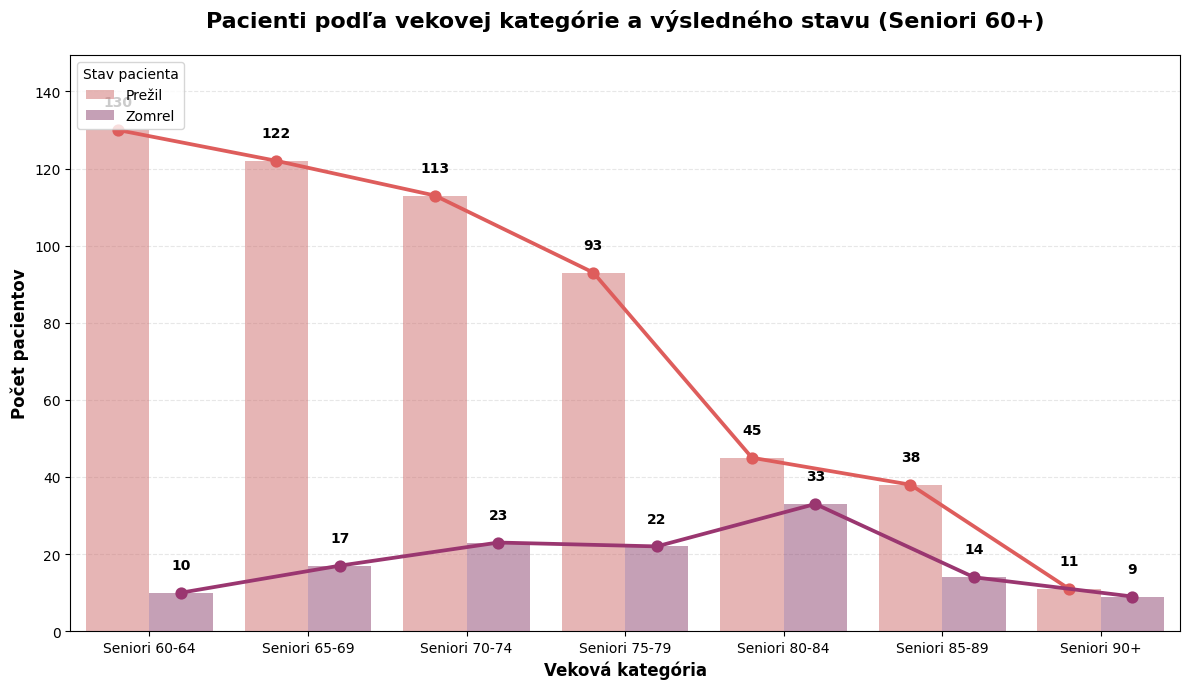

In [7]:
# Výpočet chýbajúcich hodnôt po odstránení nepotrebných atribútov

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

vek_col = first_existing_column(vlna_1, ["Vek"])
if vek_col is None:
    raise KeyError("V datasete sa nenašiel stĺpec 'Vek'.")

# Základné rozdelenie veku 
vek_kat = pd.cut(
    vlna_1[vek_col], 
    bins=[0, 18, 45, 60, 150], 
    labels=['deti_a_mládež', 'mladí_dospelí', 'stredný_vek', 'seniori'], 
    right=False
)

# Ak stĺpec už existuje z predošlého behu, vymažeme ho
if 'Vek_kategoria' in vlna_1.columns:
    vlna_1.drop(columns=['Vek_kategoria'], inplace=True)
    
vlna_1.insert(loc=vlna_1.columns.get_loc(vek_col) + 1, 
              column='Vek_kategoria', 
              value=vek_kat)

# Detailné rozdelenie seniorov (60+) na 5-ročné intervaly 
def detailni_seniori(row):
    vek = row[vek_col]
    if pd.isna(vek):
        return np.nan
    if vek < 60:
        return row['Vek_kategoria']
    elif 60 <= vek < 65:
        return 'Seniori 60-64'
    elif 65 <= vek < 70:
        return 'Seniori 65-69'
    elif 70 <= vek < 75:
        return 'Seniori 70-74'
    elif 75 <= vek < 80:
        return 'Seniori 75-79'
    elif 80 <= vek < 85:
        return 'Seniori 80-84'
    elif 85 <= vek < 90:
        return 'Seniori 85-89'
    else:
        return 'Seniori 90+'

vlna_1['Vek_kategoria'] = vlna_1.apply(detailni_seniori, axis=1)

# Vytvorenie binárnych stĺpcov z kategórie veku
vek_dummies = pd.get_dummies(vlna_1['Vek_kategoria'], prefix='Vek_kat').astype(bool)

# Určenie pozície pre vloženie (za Pohlavie)
if 'Pohlavie' in vlna_1.columns:
    pos = vlna_1.columns.get_loc('Pohlavie') + 1
else:
    pos = 0 

# Vloženie nových stĺpcov do datasetu
for col_name in reversed(vek_dummies.columns):
    if col_name in vlna_1.columns:
        vlna_1.drop(columns=[col_name], inplace=True)
    vlna_1.insert(loc=pos, column=col_name, value=vek_dummies[col_name])

# Odstránenie starých stĺpcov
stlpce_na_odstranenie = [
    vek_col, 'Vek_kategoria', 
    'Vek_kat_deti_a_mládež', 'Vek_kat_mladí_dospelí', 'Vek_kat_stredný_vek'
]
vlna_1.drop(columns=stlpce_na_odstranenie, inplace=True, errors='ignore')
print("Nadbytočné vekové kategórie (pod 60 r.) boli odstránené. V datasete pre pravidlá zostali len seniori.\n")

# KONTINGENČNÁ TABUĽKA 
vek_cols_senior = [col for col in vlna_1.columns if col.startswith('Vek_kat_Seniori')]

def urci_senior_kategoriu(row):
    for col in vek_cols_senior:
        if row[col] == True:
            return col.replace('Vek_kat_', '')
    return None  

docasna_kategoria = vlna_1.apply(urci_senior_kategoriu, axis=1)
vysledky_vek = pd.crosstab(docasna_kategoria, vlna_1['Zomrel'], dropna=True)
vysledky_vek.rename(columns={0: 'Prežil', 1: 'Zomrel'}, inplace=True)

if 'Zomrel' not in vysledky_vek.columns: vysledky_vek['Zomrel'] = 0
if 'Prežil' not in vysledky_vek.columns: vysledky_vek['Prežil'] = 0

vysledky_vek['Spolu'] = vysledky_vek['Prežil'] + vysledky_vek['Zomrel']
vysledky_vek['Úmrtnosť (%)'] = (vysledky_vek['Zomrel'] / vysledky_vek['Spolu'] * 100).round(2)
vysledky_vek = vysledky_vek.sort_index()

print("Prehľad mortality v rámci seniorských vekových kategórií:")
display(vysledky_vek)

# VIZUALIZÁCIA GRAFU 
plot_data = vysledky_vek[['Prežil', 'Zomrel']].reset_index()
nazov_indexu = plot_data.columns[0]
plot_data = plot_data.melt(id_vars=nazov_indexu, var_name='Stav', value_name='Počet')
plot_data.columns = ['Veková kategória', 'Stav', 'Počet']
plot_data['Veková kategória'] = plot_data['Veková kategória'].astype(str)

plt.figure(figsize=(12, 7))
hue_order = ['Prežil', 'Zomrel']

# A. Stĺpcový graf
ax = sns.barplot(data=plot_data, 
                 x='Veková kategória', y='Počet', hue='Stav', 
                 hue_order=hue_order, palette='flare', alpha=0.5)

# B. Spojnicový graf (Vlnky)
sns.pointplot(data=plot_data, 
              x='Veková kategória', y='Počet', hue='Stav', 
              hue_order=hue_order, palette='flare', 
              markers='o', linestyles='-', dodge=0.4, 
              errorbar=None, ax=ax)  

plt.ylim(0, plot_data['Počet'].max() * 1.15) 
ax.set_axisbelow(True) 


plt.title('Pacienti podľa vekovej kategórie a výsledného stavu (Seniori 60+)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Veková kategória', fontsize=12, fontweight='bold')
plt.ylabel('Počet pacientov', fontsize=12, fontweight='bold')


handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Stav pacienta', loc='upper left')

# Čísla nad stĺpcami
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 15), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Imputácia chýbajúcich numerických hodnôt pomocou MICE

target_col = "Zomrel"
excluded_for_selection = {target_col}

# Kategorické a binárne atribúty -> Chi-kvadrát + Cramerovo V
cat_results = []
candidate_cat_cols = []

for col in vlna_1.columns:
    if col in excluded_for_selection:
        continue
        
    
    if str(col).startswith("Vek_kat_"):
        candidate_cat_cols.append(col)
        continue

    as_bool = safe_bool_series(vlna_1[col])
    if as_bool is not None:
        candidate_cat_cols.append(col)
        continue

    if (pd.api.types.is_object_dtype(vlna_1[col]) or 
        pd.api.types.is_categorical_dtype(vlna_1[col]) or
        vlna_1[col].nunique(dropna=True) <= 10):
        candidate_cat_cols.append(col)

candidate_cat_cols = list(dict.fromkeys(candidate_cat_cols))

for col in candidate_cat_cols:
    temp = vlna_1[[col, target_col]].copy().dropna()
    if temp.empty or temp[col].nunique() < 2 or temp[target_col].nunique() < 2:
        continue

    contingency = pd.crosstab(temp[col], temp[target_col])
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    chi2, p, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denom = min((kcorr - 1), (rcorr - 1))
    cramers_v = np.sqrt(phi2corr / denom) if denom > 0 else 0.0

    cat_results.append({
        "Atribút": col,
        "Typ": "kategorický/binárny",
        "Chi2": chi2,
        "P_hodnota": p,
        "Cramerovo_V": cramers_v
    })

cat_selection_df = pd.DataFrame(cat_results).sort_values(
    by=["Cramerovo_V", "Chi2"], ascending=False
) if cat_results else pd.DataFrame(columns=["Atribút", "Typ", "Chi2", "P_hodnota", "Cramerovo_V"])

# Numerické atribúty -> Spearman 
numeric_candidates = [
    col for col in vlna_1.select_dtypes(include=[np.number]).columns
    if col not in {target_col} 
    
]

num_results = []
for col in numeric_candidates:
    temp = vlna_1[[col, target_col]].dropna()
    if temp.empty or temp[col].nunique() < 2:
        continue
    corr, p = spearmanr(temp[col], temp[target_col])
    if pd.isna(corr):
        continue
    num_results.append({
        "Atribút": col,
        "Typ": "numerický",
        "Spearman_abs": abs(float(corr)),
        "P_hodnota": float(p) if pd.notna(p) else np.nan
    })

num_selection_df = pd.DataFrame(num_results).sort_values(
    by=["Spearman_abs", "P_hodnota"], ascending=[False, True]
) if num_results else pd.DataFrame(columns=["Atribút", "Typ", "Spearman_abs", "P_hodnota"])

display(cat_selection_df.head(20))
display(num_selection_df.head(20))

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_34422/527172017.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(vlna_1[col]) or
/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_34422/527172017.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(vlna_1[col]) or
/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_34422/527172017.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(vlna_1[col]) or
/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_34422/527172017.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed 

,Atribút,Typ,Chi2,P_hodnota,Cramerovo_V
64,26846 OXANTIL,kategorický/binárny,77.782245,1.150497e-18,0.261480
6,Vek_kat_Seniori 80-84,kategorický/binárny,72.407483,1.750490e-17,0.252162
63,24949 CODEIN,kategorický/binárny,28.058215,1.177203e-07,0.155222
38,2410B HYDROCORTISONE,kategorický/binárny,23.809600,1.063507e-06,0.142515
8,Vek_kat_Seniori 90+,kategorický/binárny,18.584051,1.625750e-05,0.125129
14,Kardiovaskulárne ochorenia,kategorický/binárny,18.529119,1.673283e-05,0.124934
13,Diabetes mellitus,kategorický/binárny,16.402641,5.121382e-05,0.117110
12,Hypertenzia,kategorický/binárny,11.944208,5.481752e-04,0.098715
32,92973 ALPHA D3,kategorický/binárny,11.534082,6.833182e-04,0.096848
59,93105 DEGAN,kategorický/binárny,11.466017,7.088042e-04,0.096534


,Atribút,Typ,Spearman_abs,P_hodnota
102,S-IL6 last,numerický,0.470053,7.440691e-63
103,S-IL6 min,numerický,0.457608,2.932191e-59
54,S-CRP last,numerický,0.443752,1.991068e-55
55,S-CRP min,numerický,0.426045,8.805645e-51
170,NE/LY(NLR) last,numerický,0.399839,2.142322e-44
67,S-Urea min,numerický,0.366351,4.988894e-37
66,S-Urea last,numerický,0.366113,5.591009e-37
181,S-PBNP min,numerický,0.359994,1.003443e-35
126,Ly abs last,numerický,0.357085,3.873911e-35
104,S-IL6 max,numerický,0.349453,1.254873e-33


In [9]:
# Finálna kontrola po imputácii

import pandas as pd

# --- 1. Výber kategorických/binárnych atribútov (Chí-kvadrát)
selected_cat = []
if not cat_selection_df.empty:
    # Vyberieme (p < 0.05) zoradené podľa Cramerovho V
    selected_cat = cat_selection_df[
        (cat_selection_df["P_hodnota"] < 0.05)
    ].sort_values("Cramerovo_V", ascending=False)["Atribút"].tolist()

# Výber unikátnych  numerických markerov (Spearman) 
selected_num_raw = []
if not num_selection_df.empty:
    
    selected_num_raw = num_selection_df[
        (num_selection_df["P_hodnota"] < 0.05) & 
        (num_selection_df["Atribút"].str.contains('last', case=False))
    ].sort_values("Spearman_abs", ascending=False)["Atribút"].tolist()


senior_age_cols = [col for col in vlna_1.columns if str(col).startswith("Vek_kat_Seniori")]
for age_col in senior_age_cols:
    if age_col not in selected_cat:
        selected_cat.append(age_col)


selected_cat = list(dict.fromkeys(selected_cat))[:15]
selected_num = selected_num_raw[:15]

print(f"Vybraných {len(selected_cat)} kategorických atribútov.")
print(f"Vybraných {len(selected_num)} unikátnych 'last' markerov.")

df_items = pd.DataFrame(index=vlna_1.index)

for col in selected_cat:
    
    if str(col).startswith("Vek_kat_Seniori"):
        pretty_name = str(col).replace('Vek_kat_', '')
        df_items[pretty_name] = vlna_1[col].fillna(False).astype(bool)
        continue

    as_bool = safe_bool_series(vlna_1[col])
    if as_bool is not None:
        df_items[str(col)] = as_bool
    else:
        
        dummies = pd.get_dummies(vlna_1[col].astype(str), prefix=str(col))
        dummies = dummies[[c for c in dummies.columns if not c.endswith("_nan")]]
        for dcol in dummies.columns:
            df_items[dcol] = dummies[dcol].astype(bool)

# Binarizácia 
medical_cutoffs = {
    "S-CRP": 5.0, "S-IL6": 7.0, "D-dimér HS": 0.5, "S-AST": 0.85, 
    "S-ALT": 0.85, "S-Urea": 8.3, "S-Kreat": 104.0, "S-FER": 300.0, 
    "WBC": 10.0, "PLT": 400.0, "NE/LY(NLR)": 3.1, "S-PBNP": 300.0, 
    "S-Gluk": 5.6, "S-Chol": 5.0, "Fib": 4.0
}

for col in selected_num:
    s = vlna_1[col]
    
    base_param = str(col).replace(' last', '').strip()
    
    # Určenie threshold 
    threshold = medical_cutoffs.get(base_param, s.quantile(0.75))
    
    
    item_name = f"{base_param}_Vysoke"
    df_items[item_name] = (s > threshold).fillna(False).astype(bool)


df_items["Zomrel"] = vlna_1["Zomrel"].astype(bool)

min_item_support = 0.01
item_supports = df_items.mean()
keep_cols = item_supports[item_supports >= min_item_support].index.tolist()

if "Zomrel" not in keep_cols:
    keep_cols.append("Zomrel")
    
df_final = df_items[keep_cols].copy()

print(f"\nTransakčná matica pripravená. Počet atribútov: {df_final.shape[1]}")
print("Ukážka vyčištených názvov stĺpcov:")
print(df_final.columns.tolist())
display(df_final.head())

Vybraných 15 kategorických atribútov.
Vybraných 15 unikátnych 'last' markerov.

Transakčná matica pripravená. Počet atribútov: 30
Ukážka vyčištených názvov stĺpcov:
['26846 OXANTIL', 'Seniori 80-84', '24949 CODEIN ', '2410B HYDROCORTISONE', 'Seniori 90+', 'Kardiovaskulárne ochorenia', 'Diabetes mellitus', 'Hypertenzia', '92973 ALPHA D3', '93105 DEGAN ', 'Seniori 85-89', '3879d INOMED', '24836 | ACIDUM ASCORBICUM BBP', '84370 LAGOSA', '94918 AMBROBENE', 'S-IL6_Vysoke', 'S-CRP_Vysoke', 'NE/LY(NLR)_Vysoke', 'S-Urea_Vysoke', 'Ly abs_Vysoke', 'S-PBNP_Vysoke', 'Eo abs_Vysoke', 'Neu abs_Vysoke', 'S-Gluk_Vysoke', 'CD3+_Vysoke', 'S-Kreat_Vysoke', 'S-Ig M_Vysoke', 'D-dimér HS_Vysoke', 'S-CK-MB_Vysoke', 'Zomrel']


,26846 OXANTIL,Seniori 80-84,24949 CODEIN,2410B HYDROCORTISONE,Seniori 90+,Kardiovaskulárne ochorenia,Diabetes mellitus,Hypertenzia,92973 ALPHA D3,93105 DEGAN,...,S-PBNP_Vysoke,Eo abs_Vysoke,Neu abs_Vysoke,S-Gluk_Vysoke,CD3+_Vysoke,S-Kreat_Vysoke,S-Ig M_Vysoke,D-dimér HS_Vysoke,S-CK-MB_Vysoke,Zomrel
0,False,False,True,False,False,False,False,False,True,False,...,False,False,True,True,True,False,False,True,False,False
1,False,False,False,False,False,False,True,False,True,False,...,False,False,True,True,True,False,False,True,False,False
2,True,False,False,True,False,False,False,False,False,False,...,True,False,True,True,False,True,False,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,True,False,False,False,True,False,True,True,False,...,True,False,False,True,False,True,False,True,True,True


In [10]:
min_sup = 0.015       
min_conf = 0.45      
min_lift = 1.30      
max_rule_len = 4     

frequent_itemsets = fpgrowth(
    df_final, 
    min_support=min_sup, 
    use_colnames=True, 
    max_len=max_rule_len  
)

# Generovanie pravidiel
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_conf)

rules_filtered = rules[rules['consequents'] == frozenset({'Zomrel'})]

# Filtrovanie podľa Liftu 
rules_filtered = rules_filtered[rules_filtered['lift'] >= 1.3]

print(f"Našlo sa {len(rules_filtered)} pravidiel po filtrovaní.")

Našlo sa 214 pravidiel po filtrovaní.


In [11]:
# Diskretizácia veku a príprava vekových kategórií

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift)

rules_filtered = rules[
    (rules["consequents"].apply(lambda x: x == frozenset({"Zomrel"}))) &
    (rules["antecedents"].apply(lambda x: "Zomrel" not in x and "Vysledok_Zomrel" not in x)) &
    (rules["confidence"] >= min_conf) &
    (rules["lift"] >= min_lift)
].copy()

rules_filtered["antecedent_len"] = rules_filtered["antecedents"].apply(len)
rules_filtered = rules_filtered[
    (rules_filtered["antecedent_len"] >= 1) &
    (rules_filtered["antecedent_len"] <= max_rule_len)
]

rules_filtered["antecedent_str"] = rules_filtered["antecedents"].apply(
    lambda x: " + ".join(sorted(list(x)))
)
rules_filtered["consequent_str"] = rules_filtered["consequents"].apply(
    lambda x: " + ".join(sorted(list(x)))
)

rules_filtered = rules_filtered.drop_duplicates(
    subset=["antecedent_str", "consequent_str"]
).sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print(f"Našlo sa {len(rules_filtered)} pravidiel po filtrovaní.")
print(
    f"Thresholdy: min_support={min_sup}, min_confidence={min_conf}, "
    f"min_lift={min_lift}, max_len={max_rule_len}"
)

rules_table = rules_filtered[[
    "antecedent_str", "consequent_str", "antecedent support",
    "consequent support", "support", "confidence", "lift",
    "leverage", "conviction"
]].copy()

rules_table.columns = [
    "Antecedent", "Consequent", "Antecedent support",
    "Consequent support", "Support", "Confidence",
    "Lift", "Leverage", "Conviction"
]

display(rules_table.head(30))


Našlo sa 214 pravidiel po filtrovaní.
Thresholdy: min_support=0.015, min_confidence=0.45, min_lift=1.3, max_len=4


,Antecedent,Consequent,Antecedent support,Consequent support,Support,Confidence,Lift,Leverage,Conviction
0,26846 OXANTIL + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.021352,0.117438,0.016904,0.791667,6.741162,0.014396,4.236299
1,Neu abs_Vysoke + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.021352,0.117438,0.016014,0.750000,6.386364,0.013507,3.530249
2,26846 OXANTIL + S-Gluk_Vysoke + Seniori 80-84,Zomrel,0.023132,0.117438,0.016904,0.730769,6.222611,0.014187,3.278088
3,S-Gluk_Vysoke + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.032918,0.117438,0.023132,0.702703,5.983620,0.019266,2.968619
4,24836 | ACIDUM ASCORBICUM BBP + S-Kreat_Vysoke...,Zomrel,0.023132,0.117438,0.016014,0.692308,5.895105,0.013298,2.868327
5,NE/LY(NLR)_Vysoke + S-Kreat_Vysoke + Seniori 8...,Zomrel,0.023132,0.117438,0.016014,0.692308,5.895105,0.013298,2.868327
6,NE/LY(NLR)_Vysoke + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.036477,0.117438,0.024911,0.682927,5.815225,0.020627,2.783466
7,S-IL6_Vysoke + S-Kreat_Vysoke + Seniori 80-84,Zomrel,0.024911,0.117438,0.016904,0.678571,5.778139,0.013978,2.745749
8,S-Kreat_Vysoke + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.024911,0.117438,0.016904,0.678571,5.778139,0.013978,2.745749
9,26846 OXANTIL + S-IL6_Vysoke + Seniori 80-84,Zomrel,0.027580,0.117438,0.018683,0.677419,5.768328,0.015444,2.735943


In [12]:
vlna_1.head(10)

,Poradie,Meno,Pohlavie,Vek_kat_Seniori 60-64,Vek_kat_Seniori 65-69,Vek_kat_Seniori 70-74,Vek_kat_Seniori 75-79,Vek_kat_Seniori 80-84,Vek_kat_Seniori 85-89,Vek_kat_Seniori 90+,...,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max,Zomrel,Dlzka_hospitalizacie
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,False,False,False,True,False,False,False,...,183.000000,183.000000,183.000000,183.000000,13.170000,13.17000,13.170000,13.170000,0,7
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,False,True,False,False,False,False,False,...,101.900000,101.900000,101.900000,101.900000,36.220000,36.22000,36.220000,36.220000,0,13
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,True,False,False,False,False,False,False,...,432.700000,1216.000000,432.700000,1216.000000,6.800000,6.80000,6.800000,6.800000,1,14
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,False,True,False,False,False,False,False,...,117.700000,117.700000,117.700000,117.700000,8.490000,8.49000,8.490000,8.490000,0,5
4,5,TBHAMJTMUMUUJKDBNYED,Muž,False,False,False,False,True,False,False,...,10979.000000,10979.000000,10979.000000,10979.000000,35.060000,35.06000,35.060000,35.060000,1,3
5,6,ECHAMJTYMJIUDHFKGRCL,Žena,False,False,True,False,False,False,False,...,377.288396,-2425.924000,-492.901685,903.107918,21.957393,21.76355,21.684946,22.067132,0,3
6,7,VZHAMJYXXMJNAAPJJYUT,Muž,False,False,False,False,False,False,False,...,15.540000,282.200000,15.540000,282.200000,27.450000,27.45000,27.450000,27.450000,0,12
7,8,CVHAMJUHMBMASWPTISNN,Muž,False,False,False,False,False,False,False,...,45.590000,45.590000,45.590000,45.590000,28.760000,28.76000,28.760000,28.760000,0,5
8,9,AFHAMXHHHYAGDSHEIQPA,Žena,False,False,False,True,False,False,False,...,528.044797,257.515516,445.502280,1458.942061,11.450000,11.45000,11.450000,11.450000,0,6
9,10,AGHAMXHUYTHEKURLSXNA,Muž,False,False,False,False,True,False,False,...,576.600000,2020.000000,179.900000,2020.000000,10.940000,10.94000,10.940000,10.940000,0,33


In [13]:
# Vytvorenie transakčnej matice pre asociačné pravidlá

import re

dataset_na_kontrolu = vlna_1 

keywords = ['lieč', 'liek', 'dexam', 'oxantil', 'kortik', 'atb', 'antibiot', 'antivirot', 'remdesivir', 'isoprinosine', 'fraxiparine', 'clexane']
liekove_stlpce = [col for col in dataset_na_kontrolu.columns if any(kw in str(col).lower() for kw in keywords)]


sukl_pattern = re.compile(r'^\d{4,5}[\s\|_-]') 
kodove_stlpce = [col for col in dataset_na_kontrolu.columns if sukl_pattern.match(str(col))]


vsetky_lieky = list(set(liekove_stlpce + kodove_stlpce))


print(f"Našlo sa {len(vsetky_lieky)} stĺpcov, ktoré pravdepodobne reprezentujú lieky alebo liečbu:\n")
for col in sorted(vsetky_lieky):
    
    ukazka_hodnot = dataset_na_kontrolu[col].dropna().unique()[:3]
    print(f"{col} (Ukážka hodnôt: {ukazka_hodnot})")

Našlo sa 33 stĺpcov, ktoré pravdepodobne reprezentujú lieky alebo liečbu:

00269 | PREDNISON 5 LÉČIVA (Ukážka hodnôt: [False  True])
00449 | EREVIT 300 MG/ML (Ukážka hodnôt: [ True False])
00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK (Ukážka hodnôt: [ True False])
00584 | PYRIDOXIN LÉČIVA INJ (Ukážka hodnôt: [False  True])
02963 | PREDNISON 20 LÉČIVA (Ukážka hodnôt: [False  True])
05044 OZZION (Ukážka hodnôt: [ True False])
1275C | DEXAMETAZÓN KRKA (Ukážka hodnôt: [False  True])
24814 | CALCIFEROL BBP 7,5 MG/ML (Ukážka hodnôt: [ True False])
24836 | ACIDUM ASCORBICUM BBP (Ukážka hodnôt: [ True False])
24859 PENTOXYPHILLINUM (Ukážka hodnôt: [False  True])
24949 CODEIN  (Ukážka hodnôt: [ True False])
26846 OXANTIL (Ukážka hodnôt: [False  True])
30639 REASEC (Ukážka hodnôt: [False  True])
34045 | POLYOXIDONIUM 6 MG (Ukážka hodnôt: [ True False])
35715 Azithromycin (Ukážka hodnôt: [ True False])
39397 PANTOPRAZOL (Ukážka hodnôt: [False  True])
45954 Ceftriaxon (Ukážka hodnôt:

In [14]:
# Generovanie frekventovaných množín algoritmom Apriori

if not rules_filtered.empty:
    print(f"{'#'*60}")
    print(f"{'ZOZNAM ASOCIAČNÝCH PRAVIDIEL':^60}")
    print(f"{'#'*60}\n")

    
    for i, row in rules_filtered.iterrows():
        
        antecedents = ", ".join(list(row['antecedents']))
        consequents = ", ".join(list(row['consequents']))
        
        # Formátovaný výpis pravidla
        print(f"Pravidlo č. {i+1}:")
        print(f"  IF {antecedents}")
        print(f"  THEN {consequents}")
        
        # Výpis metrík
        #print(f"  Metriky: ")
        #print(f"    - Podpora (Support):    {row['support']:.4f}")
        #print(f"    - Spoľahlivosť (Conf.): {row['confidence']:.4f}")
        #print(f"    - Zdvih (Lift):         {row['lift']:.4f}")
        #print("-" * 60)
else:
    print("Neboli nájdené žiadne pravidlá na výpis.")

############################################################
                ZOZNAM ASOCIAČNÝCH PRAVIDIEL                
############################################################

Pravidlo č. 1:
  IF 26846 OXANTIL, Seniori 80-84, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 2:
  IF Seniori 80-84, Neu abs_Vysoke, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 3:
  IF 26846 OXANTIL, S-Gluk_Vysoke, Seniori 80-84
  THEN Zomrel
Pravidlo č. 4:
  IF S-Gluk_Vysoke, Seniori 80-84, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 5:
  IF 24836 | ACIDUM ASCORBICUM BBP, Seniori 80-84, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 6:
  IF Seniori 80-84, NE/LY(NLR)_Vysoke, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 7:
  IF Seniori 80-84, NE/LY(NLR)_Vysoke, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 8:
  IF Seniori 80-84, S-IL6_Vysoke, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 9:
  IF Seniori 80-84, S-Kreat_Vysoke, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 10:
  IF 26846 OXANTIL, Seniori 80-84, S-IL6_Vysoke
  THEN Zomrel
Pravidlo

In [15]:
# Filtrovanie pravidiel zameraných na úmrtie

if not rules_filtered.empty:
    print(f"{'#'*60}")
    print(f"{'ZOZNAM ASOCIAČNÝCH PRAVIDIEL':^60}")
    print(f"{'#'*60}\n")

    
    for i, row in rules_filtered.iterrows():
        
        antecedents = ", ".join(list(row['antecedents']))
        consequents = ", ".join(list(row['consequents']))
        
        # Formátovaný výpis pravidla
        print(f"Pravidlo č. {i+1}:")
        print(f"  IF {antecedents}")
        print(f"  THEN {consequents}")
        
        # Výpis metrík
        #print(f"  Metriky: ")
        #print(f"    - Podpora (Support):    {row['support']:.4f}")
        #print(f"    - Spoľahlivosť (Conf.): {row['confidence']:.4f}")
        #print(f"    - Zdvih (Lift):         {row['lift']:.4f}")
        #print("-" * 60)
else:
    print("Neboli nájdené žiadne pravidlá na výpis.")

############################################################
                ZOZNAM ASOCIAČNÝCH PRAVIDIEL                
############################################################

Pravidlo č. 1:
  IF 26846 OXANTIL, Seniori 80-84, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 2:
  IF Seniori 80-84, Neu abs_Vysoke, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 3:
  IF 26846 OXANTIL, S-Gluk_Vysoke, Seniori 80-84
  THEN Zomrel
Pravidlo č. 4:
  IF S-Gluk_Vysoke, Seniori 80-84, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 5:
  IF 24836 | ACIDUM ASCORBICUM BBP, Seniori 80-84, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 6:
  IF Seniori 80-84, NE/LY(NLR)_Vysoke, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 7:
  IF Seniori 80-84, NE/LY(NLR)_Vysoke, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 8:
  IF Seniori 80-84, S-IL6_Vysoke, S-Kreat_Vysoke
  THEN Zomrel
Pravidlo č. 9:
  IF Seniori 80-84, S-Kreat_Vysoke, S-Urea_Vysoke
  THEN Zomrel
Pravidlo č. 10:
  IF 26846 OXANTIL, Seniori 80-84, S-IL6_Vysoke
  THEN Zomrel
Pravidlo

In [16]:
vlna_1['S-CRP min'].describe()
vlna_1['S-IL6 max'].describe()

count    1124.000000
mean      124.808023
std       248.986665
min        -1.305609
25%        32.490000
50%        62.950000
75%       120.125000
max      4760.000000
Name: S-IL6 max, dtype: float64

In [17]:
# Kontrola dostupnosti liekových atribútov v datasete

if not rules_filtered.empty:
    out_name = "vysledne_pravidla.xlsx"
    rules_table.to_excel(out_name, index=False)
    print(f"Výsledná tabuľka pravidiel bola uložená do: {out_name}")
else:
    print("Nie sú žiadne pravidlá na export.")


Výsledná tabuľka pravidiel bola uložená do: vysledne_pravidla.xlsx


In [18]:
# Prehľadný výpis nájdených pravidiel

from IPython.display import display

zoznam_komorbidit = [
    'Hypertenzia', 'Diabetes', 'Kardiovaskulárne', 
    'Obezita', 'Chronické respiračné', 'Onkologické', 'Renálne'
]

# Získanie správnej tabuľky
try:
    df_pravidla = rules_table.copy()
except NameError:
    df_pravidla = rules_filtered.copy()


dostupne_stlpce = df_pravidla.columns.tolist()


if 'antecedents' in dostupne_stlpce:
    col_ant = 'antecedents'
    col_con = 'consequents'
elif 'Predpoklad' in dostupne_stlpce:
    col_ant = 'Predpoklad'
    col_con = 'Následok' if 'Následok' in dostupne_stlpce else 'Dôsledok'
else:
    # Ak má iný názov, vezmeme jednoducho prvý stĺpec
    col_ant = dostupne_stlpce[0]
    col_con = dostupne_stlpce[1]

# Hľadanie metrík (support, confidence, lift) bez ohľadu na veľké/malé písmená
col_sup = next((c for c in dostupne_stlpce if 'support' in c.lower()), 'support')
col_conf = next((c for c in dostupne_stlpce if 'confidence' in c.lower() or 'spolahlivost' in c.lower()), 'confidence')
col_lift = next((c for c in dostupne_stlpce if 'lift' in c.lower()), 'lift')


def obsahuje_komorbiditu(antecedent_str):
    text_pravidla = str(antecedent_str)
    for komorbidita in zoznam_komorbidit:
        if komorbidita.lower() in text_pravidla.lower():
            return True
    return False


df_pravidla['S_Komorbiditou'] = df_pravidla[col_ant].apply(obsahuje_komorbiditu)


pravidla_komorbidity = df_pravidla[df_pravidla['S_Komorbiditou'] == True]
pravidla_ostatne = df_pravidla[df_pravidla['S_Komorbiditou'] == False]

# Zoradenie podľa najsilnejších metrík

sort_cols = [col_lift, col_conf]
vypis_cols = [col_ant, col_con, col_sup, col_conf, col_lift]

top_s_komorbiditou = pravidla_komorbidity.sort_values(by=sort_cols, ascending=[False, False]).head(10)
top_bez_komorbidity = pravidla_ostatne.sort_values(by=sort_cols, ascending=[False, False]).head(10)

# =================================================================
# VÝPIS VÝSLEDKOV PRE DIPLOMOVÚ PRÁCU

print("==================================================================")
print("10 NAJZAUJÍMAVEJŠÍCH PRAVIDIEL OBSAHUJÚCICH KOMORBIDITU")
print("==================================================================")
if not top_s_komorbiditou.empty:
    display(top_s_komorbiditou[vypis_cols])
else:
    print("Nenašli sa žiadne pravidlá s definovanými komorbiditami.")

print("\n==================================================================")
print("10 NAJSILNEJŠÍCH PRAVIDIEL BEZ KOMORBIDÍT")
print("==================================================================")
if not top_bez_komorbidity.empty:
    display(top_bez_komorbidity[vypis_cols])
else:
    print("Nenašli sa žiadne pravidlá bez komorbidít.")

10 NAJZAUJÍMAVEJŠÍCH PRAVIDIEL OBSAHUJÚCICH KOMORBIDITU


,Antecedent,Consequent,Antecedent support,Confidence,Lift
24,Kardiovaskulárne ochorenia + S-Kreat_Vysoke + ...,Zomrel,0.024021,0.629630,5.361392
30,26846 OXANTIL + Diabetes mellitus + S-Kreat_Vy...,Zomrel,0.024911,0.607143,5.169913
35,26846 OXANTIL + Kardiovaskulárne ochorenia + S...,Zomrel,0.048932,0.600000,5.109091
41,Kardiovaskulárne ochorenia + S-Urea_Vysoke + S...,Zomrel,0.034698,0.589744,5.021756
46,26846 OXANTIL + Hypertenzia + S-Kreat_Vysoke,Zomrel,0.044484,0.580000,4.938788
51,26846 OXANTIL + Kardiovaskulárne ochorenia + S...,Zomrel,0.082740,0.569892,4.852721
62,Hypertenzia + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.030249,0.558824,4.758467
70,26846 OXANTIL + Diabetes mellitus + S-Urea_Vysoke,Zomrel,0.039146,0.545455,4.644628
77,26846 OXANTIL + Hypertenzia + S-Urea_Vysoke,Zomrel,0.076512,0.534884,4.554616
100,Kardiovaskulárne ochorenia + Neu abs_Vysoke + ...,Zomrel,0.053381,0.516667,4.399495



10 NAJSILNEJŠÍCH PRAVIDIEL BEZ KOMORBIDÍT


,Antecedent,Consequent,Antecedent support,Confidence,Lift
0,26846 OXANTIL + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.021352,0.791667,6.741162
1,Neu abs_Vysoke + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.021352,0.750000,6.386364
2,26846 OXANTIL + S-Gluk_Vysoke + Seniori 80-84,Zomrel,0.023132,0.730769,6.222611
3,S-Gluk_Vysoke + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.032918,0.702703,5.983620
4,24836 | ACIDUM ASCORBICUM BBP + S-Kreat_Vysoke...,Zomrel,0.023132,0.692308,5.895105
5,NE/LY(NLR)_Vysoke + S-Kreat_Vysoke + Seniori 8...,Zomrel,0.023132,0.692308,5.895105
6,NE/LY(NLR)_Vysoke + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.036477,0.682927,5.815225
7,S-IL6_Vysoke + S-Kreat_Vysoke + Seniori 80-84,Zomrel,0.024911,0.678571,5.778139
8,S-Kreat_Vysoke + S-Urea_Vysoke + Seniori 80-84,Zomrel,0.024911,0.678571,5.778139
9,26846 OXANTIL + S-IL6_Vysoke + Seniori 80-84,Zomrel,0.027580,0.677419,5.768328


In [19]:
import pandas as pd
from IPython.display import display

hladane_pravidlo = "NE/LY(NLR) min_Vysoke + S-Urea last_Vysoke + Seniori 80-84"

# Rozdelenie pravidla 
podmienky = [p.strip() for p in hladane_pravidlo.split('+')]

# Slovník medicínskych noriem pre porovnanie
referencne_normy = {
    "S-CRP": "0.0 - 5.0 mg/L",
    "S-IL6": "0.0 - 7.0 pg/mL",
    "D-dimér HS": "0.0 - 0.5 mg/L",
    "S-Urea": "2.5 - 8.3 mmol/L",
    "S-Kreat": "62 - 104 umol/L",
    "NE/LY(NLR)": "1.0 - 3.1 (pomer)",
    "S-PBNP": "0 - 300 pg/mL",
    "S-Gluk": "3.3 - 5.6 mmol/L",
    "WBC": "4.0 - 10.0 10^9/L",
    "PLT": "150 - 400 10^9/L",
    "Fib": "2.0 - 4.0 g/L"
}

# VÝBER PACIENTOV
maska_pacientov = df_items['Zomrel'] == True
for p in podmienky:
    if p in df_items.columns:
        maska_pacientov = maska_pacientov & (df_items[p] == True)

indexy_pacientov = df_items[maska_pacientov].index
pocet_pacientov = len(indexy_pacientov)

print(f"==========================================================")
print(f"ANALÝZA PRAVIDLA: {hladane_pravidlo} -> Zomrel")
print(f"==========================================================")

if pocet_pacientov > 0:
    
    original_stlpce = []
    if 'Vek' in vlna_1.columns: original_stlpce.append('Vek')
        
    for p in podmienky:
        orig_nazov = p.replace('_Vysoke', '').replace('_Nizke', '').strip()
        
        if orig_nazov in vlna_1.columns and orig_nazov not in original_stlpce:
            original_stlpce.append(orig_nazov)
    
    if len(original_stlpce) > 0:
        realne_data_pacientov = vlna_1.loc[indexy_pacientov, original_stlpce]
        
        # --- TABUĽKA REFERENČNÝCH NORIEM ---
        print("💡 LEKÁRSKE REFERENČNÉ NORMY (Pre porovnanie):")
        normy_list = []
        for col in original_stlpce:
            base = col.replace(' last','').replace(' first','').replace(' min','').replace(' max','')
            normy_list.append({"Atribút": col, "Normálna hodnota (Zdravý človek)": referencne_normy.get(base, "Individuálne / Neudaná")})
        
        display(pd.DataFrame(normy_list).set_index("Atribút"))
        print("-" * 60)

        
        print("ŠTATISTIKA TEJTO SKUPINY PACIENTOV (Kritické stavy):")
        statistika = realne_data_pacientov.describe().loc[['mean', 'min', 'max']]
        statistika = statistika.rename(index={'mean': 'Priemer v skupine', 'min': 'Minimum v skupine', 'max': 'Maximum v skupine'})
        display(statistika.round(2))
        
        print("\nUKÁŽKA KONKRÉTNYCH PACIENTOV (Anonymizované ID):")
        display(realne_data_pacientov.head(5))
    else:
        print("Nenašli sa číselné údaje pre toto pravidlo.")
else:
    print("Žiadny pacient nespĺňa túto kombináciu podmienok.")

ANALÝZA PRAVIDLA: NE/LY(NLR) min_Vysoke + S-Urea last_Vysoke + Seniori 80-84 -> Zomrel
💡 LEKÁRSKE REFERENČNÉ NORMY (Pre porovnanie):


,Normálna hodnota (Zdravý človek)
Atribút,
NE/LY(NLR) min,1.0 - 3.1 (pomer)
S-Urea last,2.5 - 8.3 mmol/L


------------------------------------------------------------
ŠTATISTIKA TEJTO SKUPINY PACIENTOV (Kritické stavy):


,NE/LY(NLR) min,S-Urea last
Priemer v skupine,10.66,15.87
Minimum v skupine,0.03,4.86
Maximum v skupine,44.11,40.13



UKÁŽKA KONKRÉTNYCH PACIENTOV (Anonymizované ID):


,NE/LY(NLR) min,S-Urea last
4,6.35,19.20
13,21.45,16.95
37,12.05,14.09
89,7.49,23.98
92,8.81,8.59


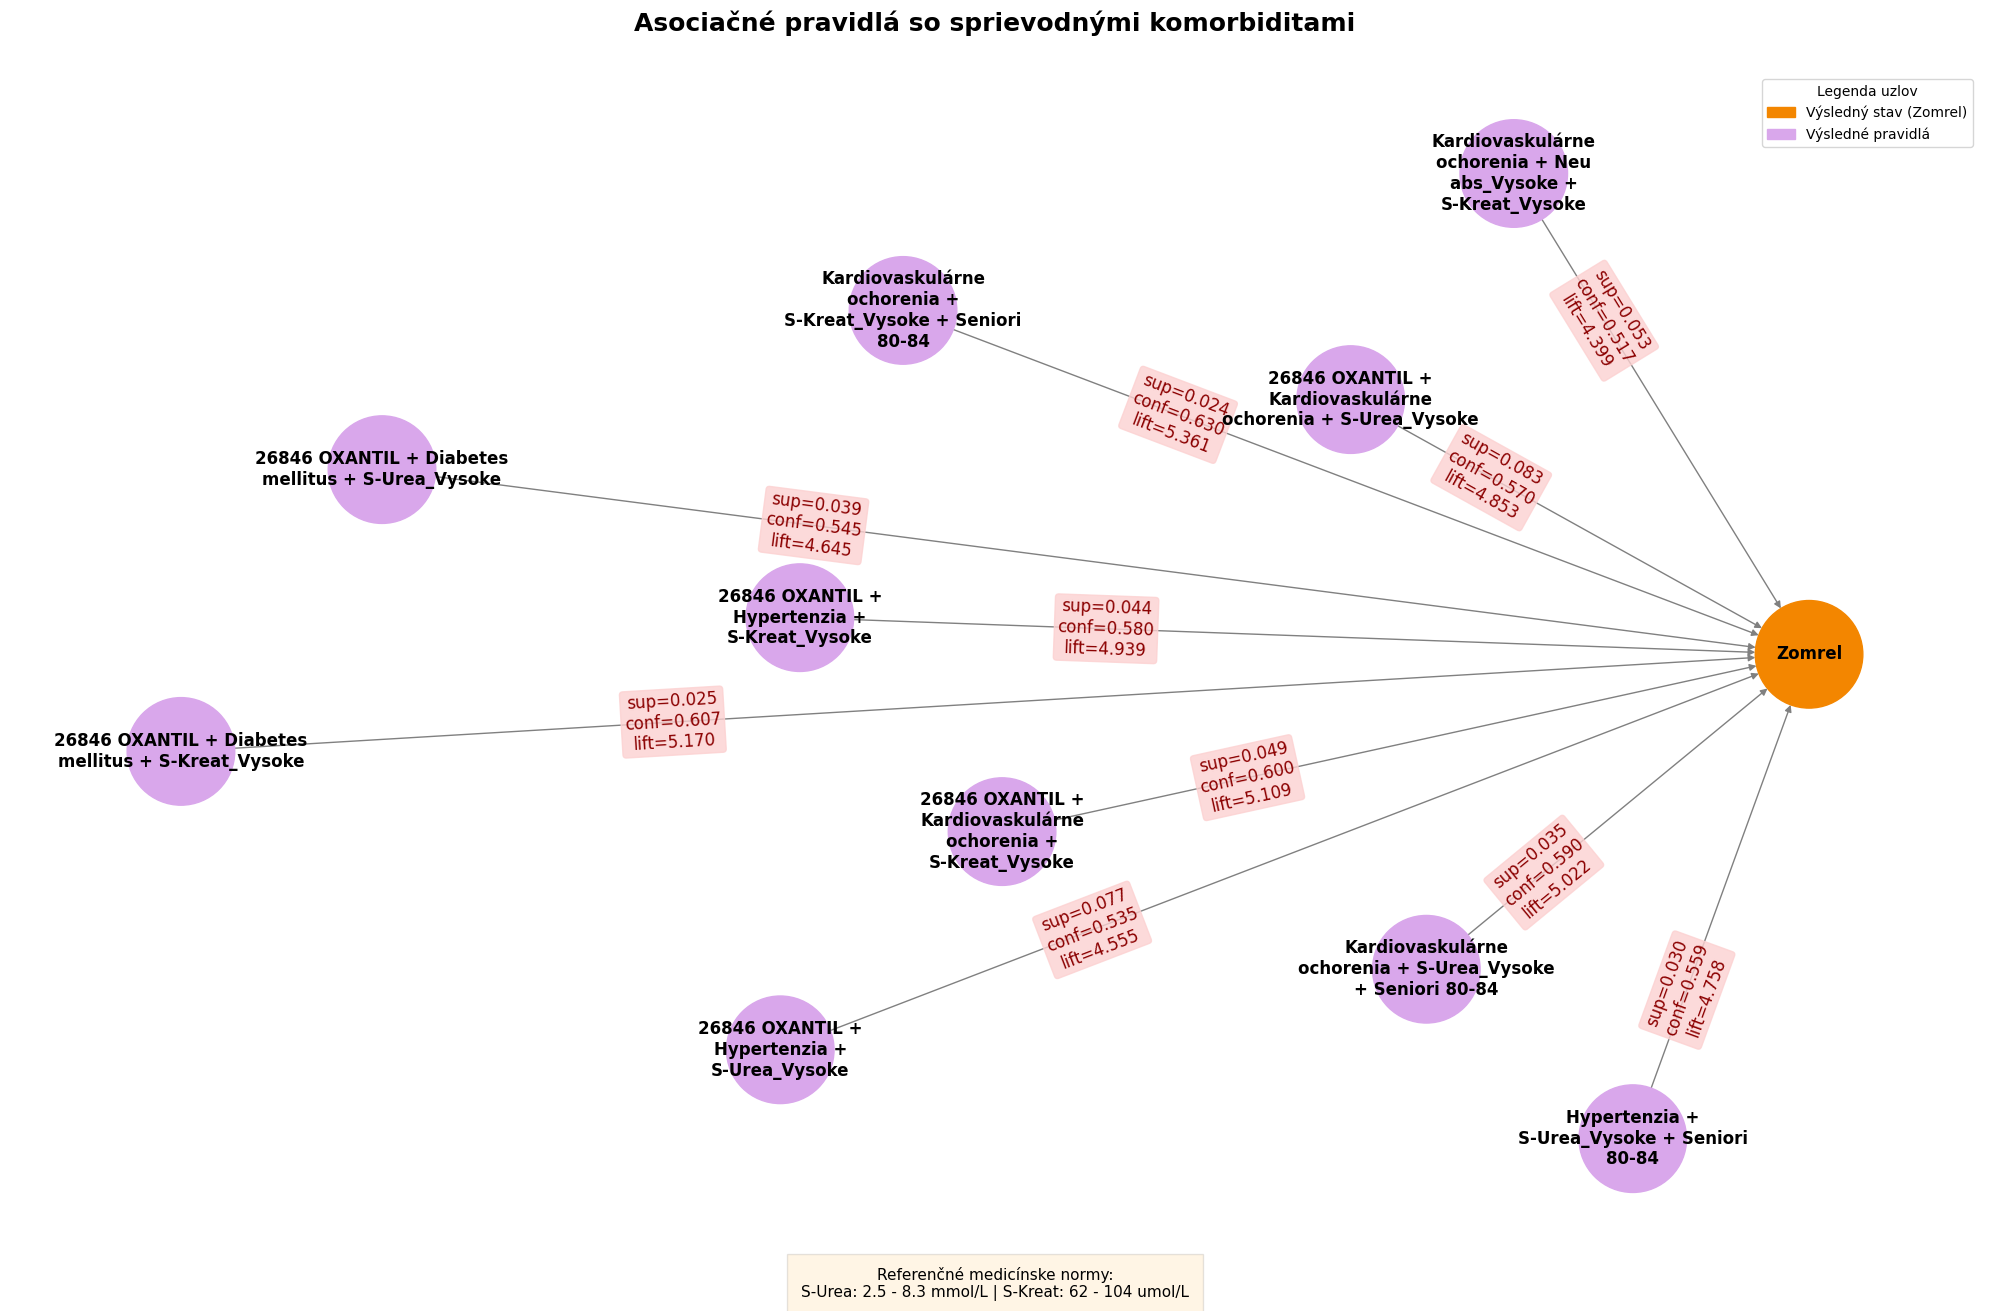

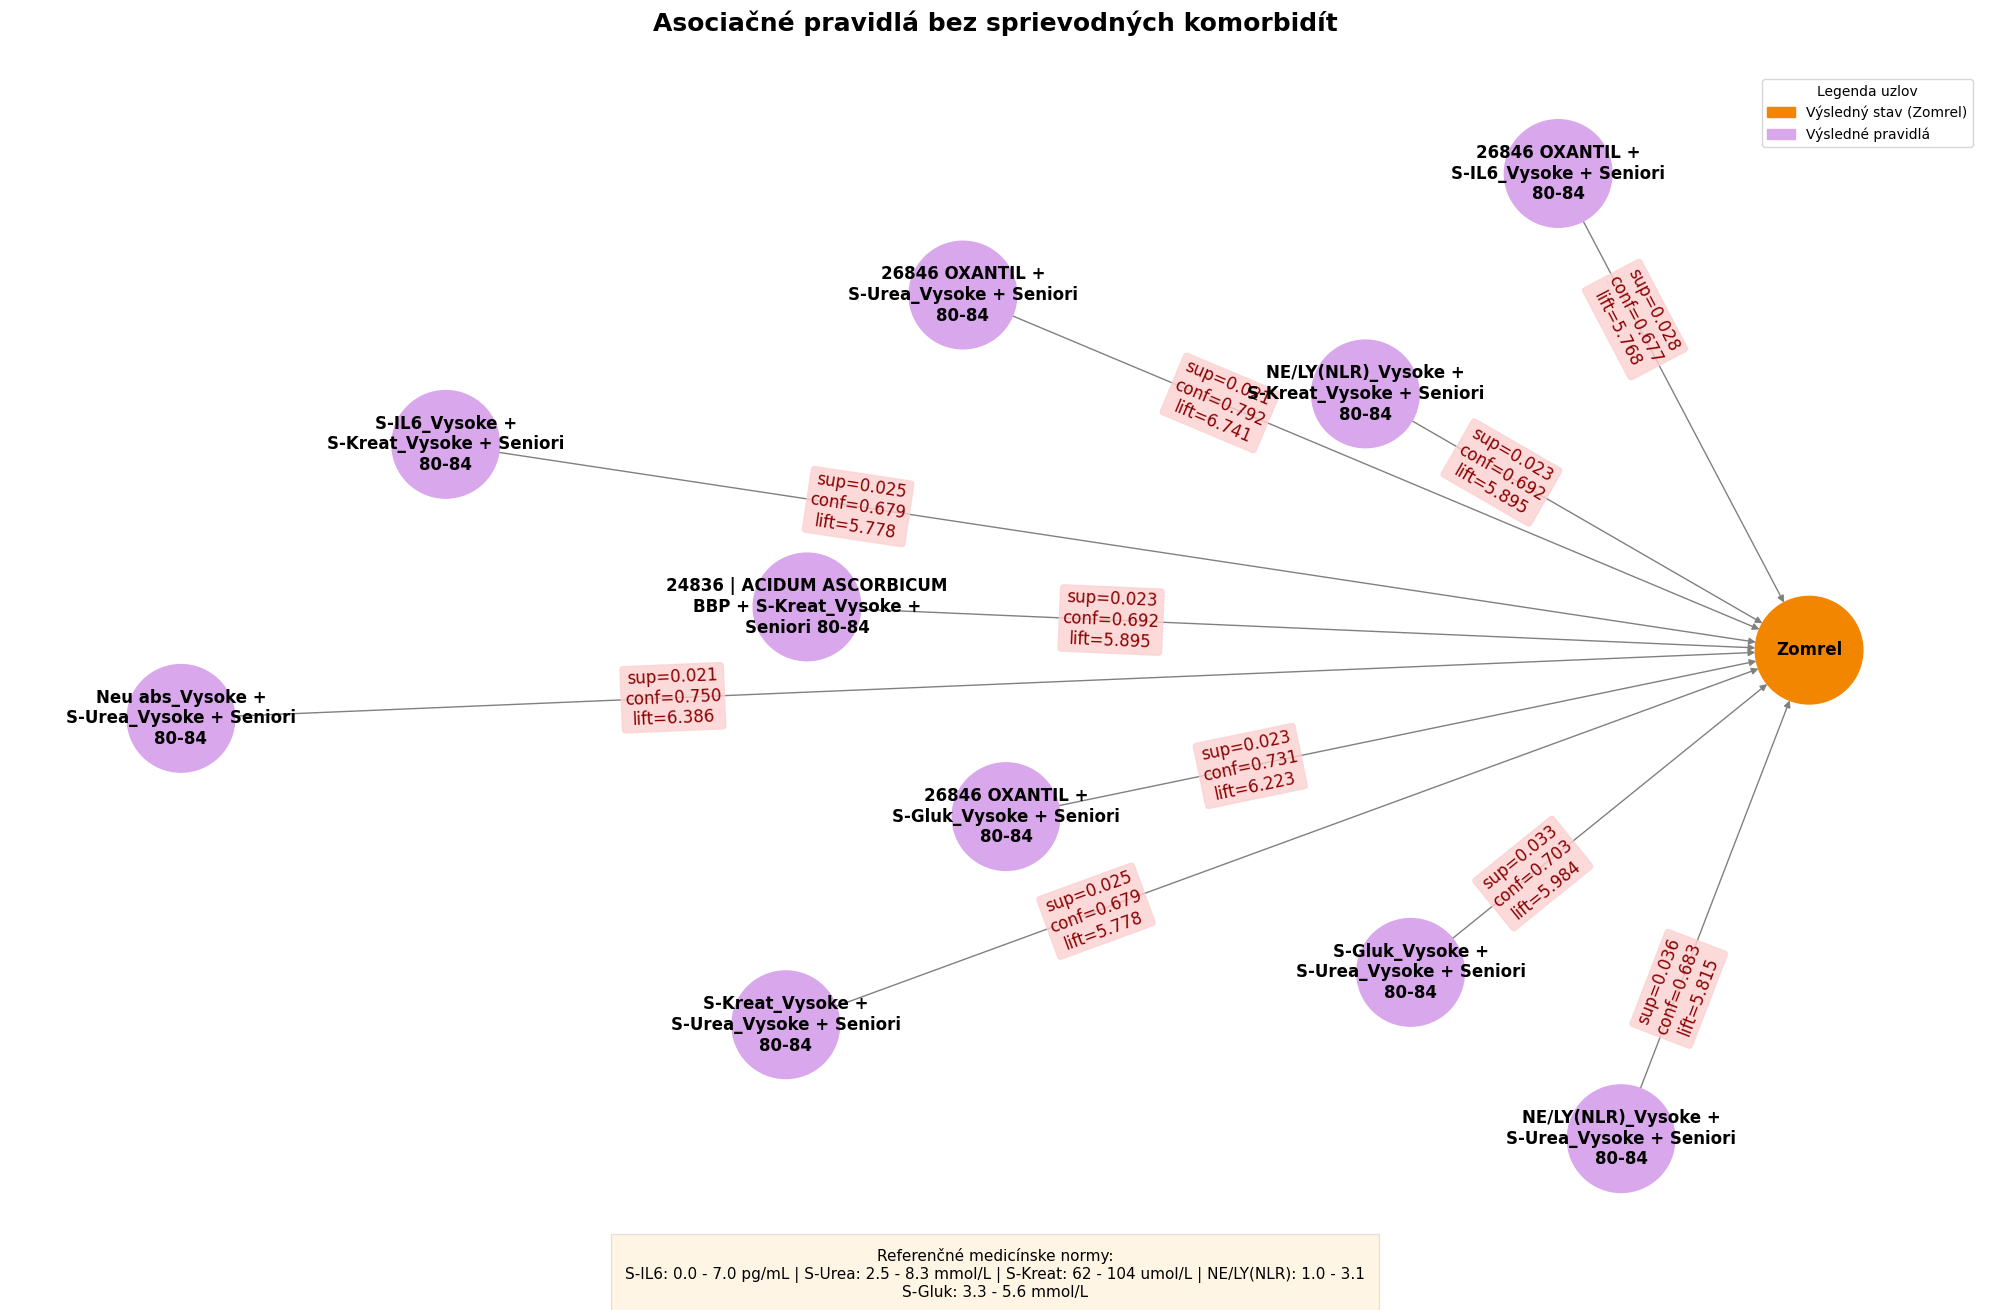

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap 

# Vykreslenie Sieťových grafov
def plot_custom_network(df, title, filename, normy):
    if df.empty:
        print(f"Tabuľka pre '{title}' je prázdna.")
        return

    
    fig, ax = plt.subplots(figsize=(20, 14))
    G = nx.DiGraph()
    parametre_v_grafe = set()

    for _, row in df.iterrows():
        ant = str(row["Antecedent"]).replace("frozenset({", "").replace("})", "").replace("'", "")
        con = str(row["Consequent"]).replace("frozenset({", "").replace("})", "").replace("'", "")
        
        for p in ant.split(" + "):
            parametre_v_grafe.add(p.replace("Vysoke", "").strip())

        label = f"sup={row.get('Antecedent support', 0):.3f}\nconf={row['Confidence']:.3f}\nlift={row['Lift']:.3f}"
        G.add_edge(ant, con, label=label, weight=row["Lift"])

    
    pos = nx.spring_layout(G, k=0.6, seed=20) 

    
    node_colors = []
    for node in G.nodes():
        node_str = str(node).lower()
        if "zomrel" in node_str:
            node_colors.append("#f38600")
        else:
            node_colors.append("#d9a7eb")

    
    nx.draw(
        G, pos,
        with_labels=False, 
        node_size=6000,
        node_color=node_colors,
        edge_color="gray",
        width=1,
        arrows=True,
        ax=ax
    )

    
    def text_zalomenie(text, width=25):
        clean_text = text.replace(" + ", " + ")
        return textwrap.fill(clean_text, width=width)

    wrapped_labels = {n: text_zalomenie(n) for n in G.nodes()}

    nx.draw_networkx_labels(
        G, pos,
        labels=wrapped_labels,
        font_size=12, 
        font_weight="bold",
        horizontalalignment='center',
        verticalalignment='center',
        ax=ax
    )

    
    edge_attr = nx.get_edge_attributes(G, "label")
    
    
    edge_labels = edge_attr 

    nx.draw_networkx_edge_labels(
        G, pos, 
        edge_labels=edge_labels, 
        font_color="darkred", 
        
        font_size=12, 
        label_pos=0.3, 
        rotate=True,
        
        bbox=dict(
            facecolor="#FCD1D1", 
            edgecolor='#FCD1D1', 
            alpha=0.8,           
            boxstyle='round,pad=0.2' 
        )
    )

    
    red_patch = mpatches.Patch(color="#f38600", label='Výsledný stav (Zomrel)')
    blue_patch = mpatches.Patch(color="#d9a7eb", label='Výsledné pravidlá')
    plt.legend(handles=[red_patch, blue_patch], loc='upper right', title="Legenda uzlov")

    riadky = [f"{p}: {normy[p]}" for p in normy if any(p in pg for pg in parametre_v_grafe)]
    chunks = [riadky[i:i + 4] for i in range(0, len(riadky), 4)]
    final_text = "Referenčné medicínske normy:\n" + "\n".join([" | ".join(chunk) for chunk in chunks])

    plt.figtext(0.5, 0.02, final_text, ha="center", fontsize=11, 
                bbox={"facecolor":"orange", "alpha":0.1, "pad":10})

    plt.title(title, fontsize=18, fontweight='bold', pad=30)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(filename, dpi=300)
    plt.show()


# Definícia noriem
referencne_normy = {
    "S-CRP": "0.0 - 5.0 mg/L",
    "S-IL6": "0.0 - 7.0 pg/mL",
    "D-dimér HS": "0.0 - 0.5 mg/L",
    "S-Urea": "2.5 - 8.3 mmol/L",
    "S-Kreat": "62 - 104 umol/L",
    "NE/LY(NLR)": "1.0 - 3.1",
    "S-PBNP": "0 - 300 pg/mL",
    "S-Gluk": "3.3 - 5.6 mmol/L",
    "WBC": "4.0 - 10.0 10^9/L",
    "PLT": "150 - 400 10^9/L",
    "Fib": "2.0 - 4.0 g/L"
}

# Volanie funkcií 
plot_custom_network(top_s_komorbiditou.head(10), 
                    "Asociačné pravidlá so sprievodnými komorbiditami", 
                    "graf_komorbidity.png", referencne_normy)

plot_custom_network(top_bez_komorbidity.head(10), 
                    "Asociačné pravidlá bez sprievodných komorbidít", 
                    "graf_bez_komorbidit.png", referencne_normy)

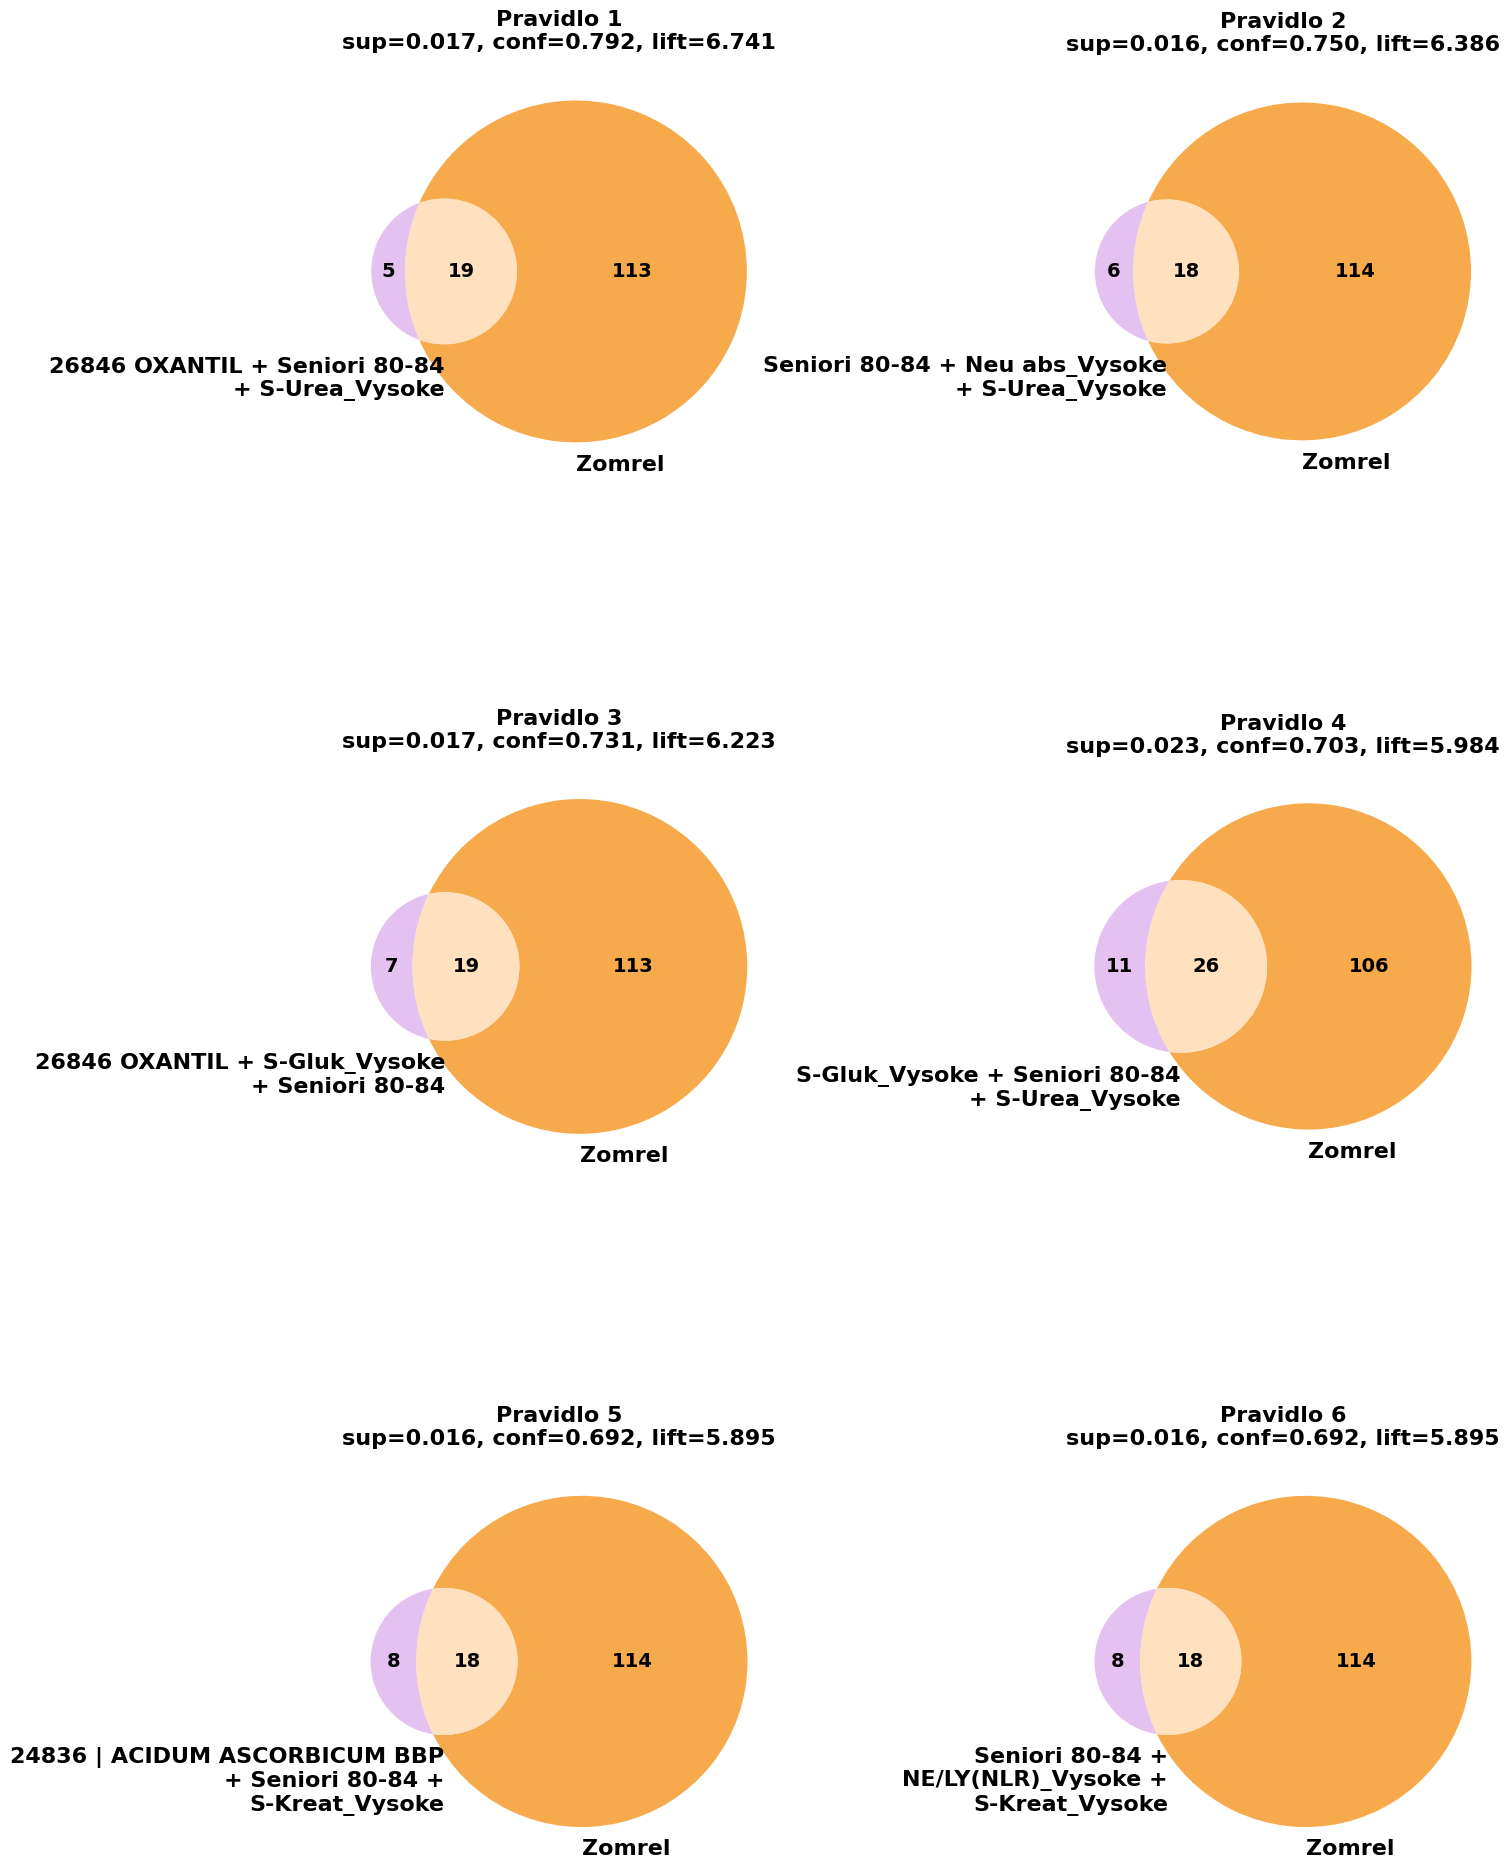

In [21]:
# Export výsledných pravidiel do Excelu

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import math
import textwrap 

# Vennove diagramy pre pravidlá zo sieťového grafu

if rules_filtered.empty:
    print("Nie sú dostupné pravidlá pre Vennove diagramy.")
else:
    plot_rules = rules_filtered.head(min(6, len(rules_filtered))).copy()
    n_rules = len(plot_rules)
    cols = 2
    rows = math.ceil(n_rules / cols)

    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 7 * rows))
    axes = np.array(axes).reshape(-1)

    for ax_idx, (_, rule) in enumerate(plot_rules.iterrows()):
        ax = axes[ax_idx]

        antecedents = list(rule["antecedents"])
        consequents = list(rule["consequents"])

        antecedent_mask = pd.Series(True, index=df_final.index)
        for item in antecedents:
            if item in df_final.columns:
                antecedent_mask &= df_final[item]

        consequent_item = list(consequents)[0]
        consequent_mask = df_final[consequent_item]

        antecedent_only = int((antecedent_mask & ~consequent_mask).sum())
        consequent_only = int((~antecedent_mask & consequent_mask).sum())
        intersection = int((antecedent_mask & consequent_mask).sum())

        
        label_ant = textwrap.fill(" + ".join(antecedents), width=30)
        label_con = textwrap.fill(consequent_item, width=30)

        v = venn2(
            subsets=(antecedent_only, consequent_only, intersection),
            set_labels=(label_ant, label_con),
            set_colors=('#d9a7eb', '#f38600'), 
            alpha=0.7,                         
            ax=ax
        )
        
        
        if v is not None:
            
            for text in v.subset_labels:
                if text is not None:
                    text.set_fontsize(14)
                    text.set_fontweight('bold')
            
            
            for text in v.set_labels:
                if text is not None:
                    text.set_fontsize(16)
                    text.set_fontweight('bold')

        
        ax.set_title(
            f"Pravidlo {ax_idx + 1}\n"
            f"sup={rule['support']:.3f}, conf={rule['confidence']:.3f}, lift={rule['lift']:.3f}",
            fontsize=16,          
            fontweight='bold',
            pad=15                
        )

    
    for j in range(ax_idx + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()